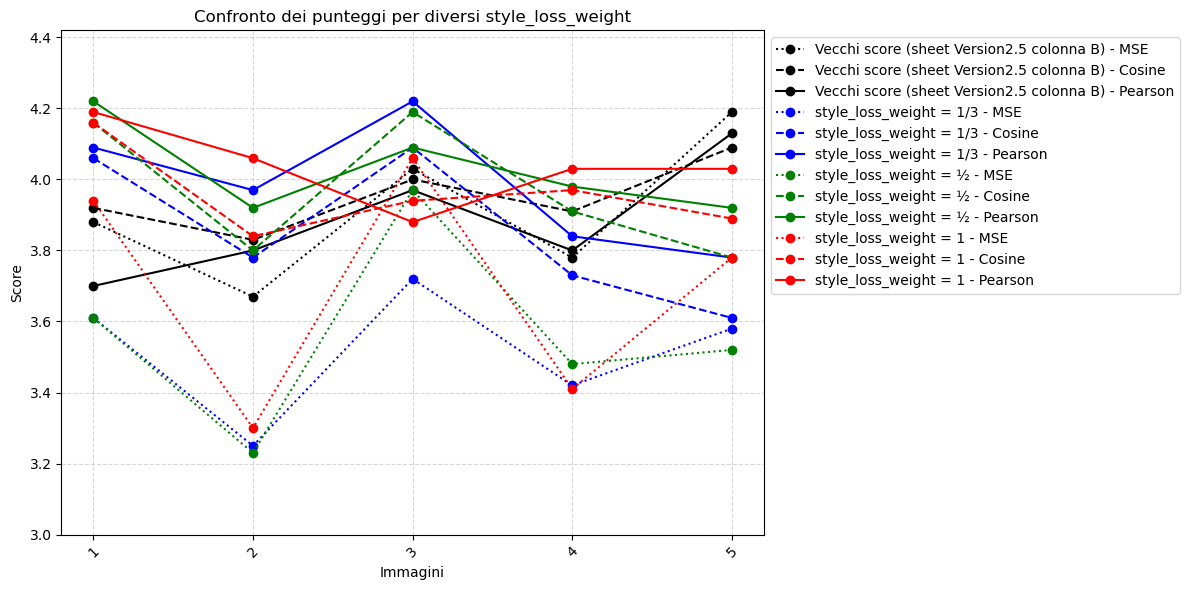

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 📥 Leggi il file CSV
file_path = "auto_weight_loss.csv"
df_raw = pd.read_csv(file_path, header=None)

# 📦 Parsing dei dati
groups = {}
current_group = None
for i, row in df_raw.iterrows():
    if isinstance(row[0], str) and (
        "Vecchi score" in row[0] or "style_loss_weight" in row[0]
    ):
        current_group = row[0].strip()
        groups[current_group] = []
    else:
        groups[current_group].append(row)

# 📊 Costruisci DataFrame per ogni gruppo
tables = {}
for group_name, rows in groups.items():
    df = pd.DataFrame(rows)
    df.columns = ["Metric"] + df.columns.tolist()[1:]
    df = df.set_index("Metric")
    df = df.apply(pd.to_numeric, errors='coerce')  # conversione numerica
    tables[group_name] = df

# 🎨 Stili e colori
line_styles = {
    "MSE": ":",
    "Cosine": "--",
    "Pearson": "-"
}
group_colors = {
    "Vecchi score (sheet Version2.5 colonna B)": "black",
    "style_loss_weight = 1/3": "blue",
    "style_loss_weight = ½": "green",
    "style_loss_weight = 1": "red"
}

# 📈 Crea il grafico
plt.figure(figsize=(12, 6))
x_labels = tables["Vecchi score (sheet Version2.5 colonna B)"].columns.tolist()
x = range(len(x_labels))

for group_name, table in tables.items():
    for metric in ["MSE", "Cosine", "Pearson"]:
        if metric in table.index:
            y = table.loc[metric].values
            if len(y) == len(x):
                plt.plot(
                    x,
                    y,
                    label=f"{group_name} - {metric}",
                    linestyle=line_styles[metric],
                    color=group_colors.get(group_name, "gray"),
                    marker='o'
                )

# 🧭 Personalizza il grafico
plt.xticks(x, x_labels, rotation=45)
plt.ylim(3.0, max(table.max().max() for table in tables.values()) + 0.2)
plt.ylabel("Score")
plt.xlabel("Immagini")
plt.title("Confronto dei punteggi per diversi style_loss_weight")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# 📤 Mostra il grafico
plt.show()


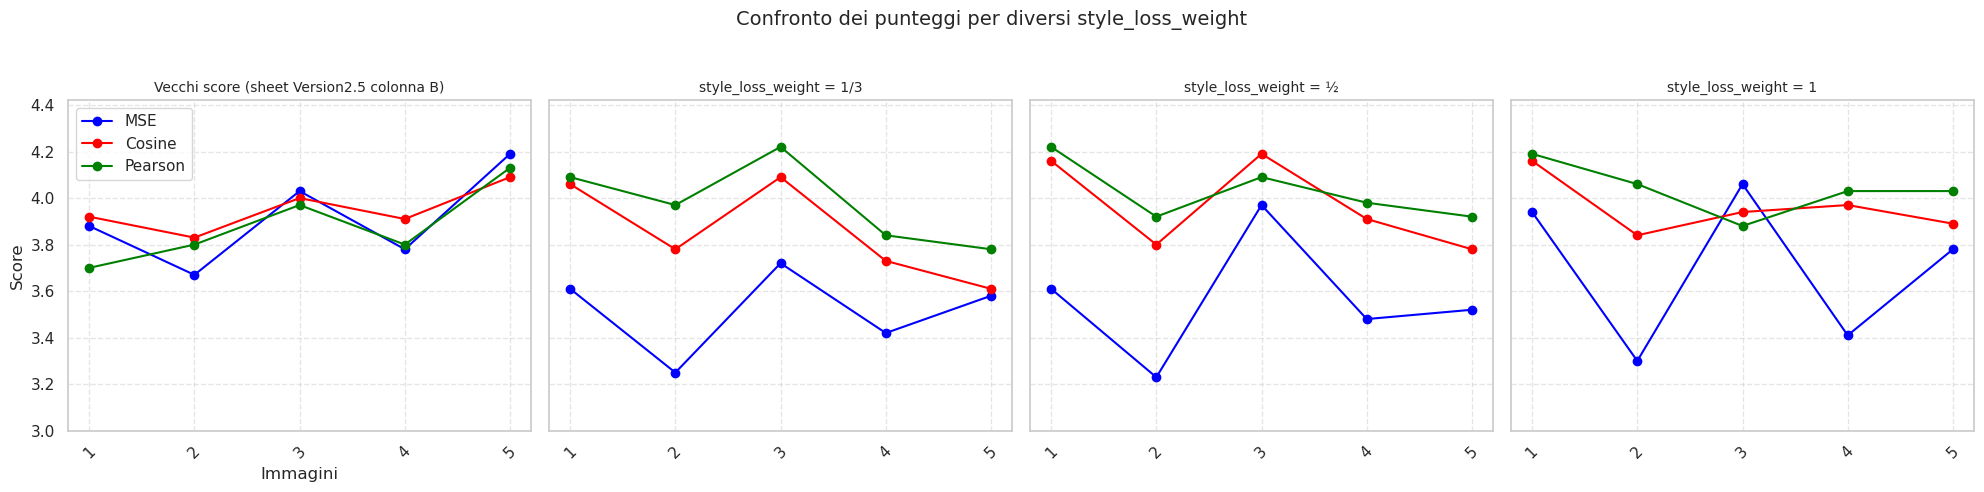

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 📥 Leggi il file CSV
file_path = "auto_weight_loss.csv"
df_raw = pd.read_csv(file_path, header=None)

# 📦 Parsing dei dati
groups = {}
current_group = None
for i, row in df_raw.iterrows():
    if isinstance(row[0], str) and (
        "Vecchi score" in row[0] or "style_loss_weight" in row[0]
    ):
        current_group = row[0].strip()
        groups[current_group] = []
    else:
        groups[current_group].append(row)

# 📊 Costruisci DataFrame per ogni gruppo
tables = {}
for group_name, rows in groups.items():
    df = pd.DataFrame(rows)
    df.columns = ["Metric"] + df.columns.tolist()[1:]
    df = df.set_index("Metric")
    df = df.apply(pd.to_numeric, errors='coerce')  # conversione numerica
    tables[group_name] = df

# 🎨 Colori per i metodi
metric_colors = {
    "MSE": "blue",
    "Cosine": "red",
    "Pearson": "green"
}

# 📋 Ordine dei gruppi
group_order = [
    "Vecchi score (sheet Version2.5 colonna B)",
    "style_loss_weight = 1/3",
    "style_loss_weight = ½",
    "style_loss_weight = 1"
]

# 📐 Imposta la figura con 4 sottofigure
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
x_labels = tables[group_order[0]].columns.tolist()
x = range(len(x_labels))

# 📈 Trova il massimo valore Y per uniformare la scala
y_max = max(table.max().max() for table in tables.values()) + 0.2

# 🔁 Disegna ogni sottofigura
for idx, group_name in enumerate(group_order):
    ax = axes[idx]
    table = tables[group_name]
    for metric in ["MSE", "Cosine", "Pearson"]:
        if metric in table.index:
            y = table.loc[metric].values
            if len(y) == len(x):
                ax.plot(
                    x,
                    y,
                    label=metric,
                    linestyle='-',
                    color=metric_colors[metric],
                    marker='o'
                )
    ax.set_title(group_name, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylim(3.0, y_max)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        ax.set_ylabel("Score")
        ax.set_xlabel("Immagini")
        ax.legend(loc='upper left')

# 🎯 Layout finale
plt.suptitle("Confronto dei punteggi per diversi style_loss_weight", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
